# Tutorial 3f: Standalone & Global Optimizers


Some optimizers are not accessible via `minimize()`, by design.  This tutorial covers:

- **GlassExpert** - discrete glass selection
- **OrthogonalDescent** - derivative-free orthogonal search
- **ParticleSwarm** - population-based global search
- **SciPy global methods** - accessible via `minimize()` (differential evolution, dual
  annealing, basin-hopping)
- A decision guide for choosing among them


## 1. The standalone fence

`GlassExpert`, `OrthogonalDescent`, and `ParticleSwarm` have their own interfaces because
they have fundamentally different semantics that do not fit the `minimize()` contract:

- **GlassExpert** searches a *discrete* glass catalog; there is no continuous gradient
  and no scalar step size.  It modifies material assignments, not just numeric parameters.
- **OrthogonalDescent** uses no derivatives at all; it explores the parameter space
  along coordinate axes.  Its convergence guarantee differs from smooth local minimizers.
- **ParticleSwarm** maintains a *population* of candidate solutions simultaneously;
  the notion of a single current iterate (central to `minimize()`) does not apply.

These optimizers **do not return** an `OptimizationResult`.  They modify the `Optic`
in-place; inspect the result by calling `problem.info()` afterwards.


In [1]:
import copy

import numpy as np

from optiland import optic
from optiland.optimization import (
    minimize,
    OptimizationProblem,
    GlassExpert,
    OrthogonalDescent,
    ParticleSwarm,
)

import optiland.backend as be


## 2. Helper - build a doublet

We reuse a simple air-spaced doublet across all examples.  A factory function ensures
each section starts from the same initial state.

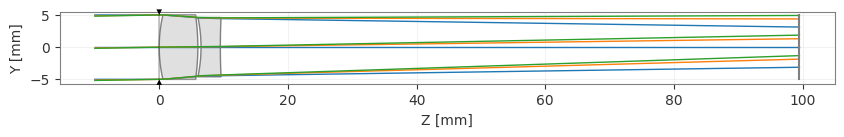

In [2]:
def build_doublet():
    """Return a fresh air-spaced doublet Optic."""
    lens = optic.Optic()
    lens.surfaces.add(index=0, thickness=np.inf)
    lens.surfaces.add(index=1, thickness=6.0, radius=22.0, material='N-BK7', is_stop=True)
    lens.surfaces.add(index=2, thickness=0.5, radius=-35.0)
    lens.surfaces.add(index=3, thickness=3.0, radius=-22.0, material='N-SF5')
    lens.surfaces.add(index=4, thickness=90.0, radius=100.0)
    lens.surfaces.add(index=5)
    lens.set_aperture(aperture_type='EPD', value=10)
    lens.fields.set_type('angle')
    lens.fields.add(y=0.0)
    lens.fields.add(y=0.7)
    lens.fields.add(y=1.0)
    lens.wavelengths.add(value=0.4861)
    lens.wavelengths.add(value=0.5876, is_primary=True)
    lens.wavelengths.add(value=0.6563)
    return lens


def build_geom_problem(lens):
    """Geometry-only optimization problem (radii + image distance)."""
    problem = OptimizationProblem()
    for Hx, Hy in lens.fields.get_field_coords():
        input_data = {
            'optic': lens, 'surface_number': -1,
            'Hx': Hx, 'Hy': Hy,
            'num_rays': 5, 'wavelength': 0.5876,
            'distribution': 'hexapolar',
        }
        problem.add_operand('rms_spot_size', target=0, weight=1, input_data=input_data)
    problem.add_operand('f2', target=100, weight=2, input_data={'optic': lens})
    for s in [1, 2, 3, 4]:
        problem.add_variable(lens, 'radius', surface_number=s, min_val=-500, max_val=500)
    problem.add_variable(lens, 'thickness', surface_number=4, min_val=50, max_val=200)
    return problem


lens_ref = build_doublet()
_ = lens_ref.draw()

## 3. GlassExpert - discrete glass optimization

`GlassExpert` searches a user-supplied list of catalog glasses and assigns the best
combination to the refractive elements.  It operates on **material variables** that
you add to the problem via `add_variable(..., type='material', glass_selection=[...])`.
It evaluates the merit function for each candidate combination and keeps the glass
assignment that yields the lowest value.

**Key points:**

- Add **material variables** to the problem, each with a `glass_selection` list.
- Call `.run()` - there is no return value.  The optic is modified in-place.
- After `.run()`, call `problem.info()` to inspect the result.


In [4]:
lens_ge = build_doublet()

problem_ge = OptimizationProblem()
for Hx, Hy in lens_ge.fields.get_field_coords():
    input_data = {
        'optic': lens_ge, 'surface_number': -1,
        'Hx': Hx, 'Hy': Hy,
        'num_rays': 5, 'wavelength': 0.5876,
        'distribution': 'hexapolar',
    }
    problem_ge.add_operand('rms_spot_size', target=0, weight=1, input_data=input_data)
problem_ge.add_operand('f2', target=100, weight=2, input_data={'optic': lens_ge})

# Geometry variables
for s in [1, 2, 3, 4]:
    problem_ge.add_variable(lens_ge, 'radius', surface_number=s, min_val=-500, max_val=500)
problem_ge.add_variable(lens_ge, 'thickness', surface_number=4, min_val=50, max_val=200)

# Material variables — GlassExpert searches these
glass_list = ['N-BK7', 'N-SK16', 'N-SF5', 'N-SF11', 'N-F2', 'N-BAK1']
problem_ge.add_variable(lens_ge, 'material', surface_number=1, glass_selection=glass_list)
problem_ge.add_variable(lens_ge, 'material', surface_number=3, glass_selection=glass_list)

print('Merit before GlassExpert:', float(be.to_numpy(problem_ge.sum_squared())))

expert = GlassExpert(problem_ge)
expert.run(num_neighbours=5, verbose=False)

print('Merit after  GlassExpert:', float(be.to_numpy(problem_ge.sum_squared())))
problem_ge.info()
lens_ge.info()

Merit before GlassExpert: 50981.724507732084
Merit after  GlassExpert: 2.5200197349098637e-05
╒════╤════════════════════════╤═══════════════════╕
│    │   Merit Function Value │   Improvement (%) │
╞════╪════════════════════════╪═══════════════════╡
│  0 │            2.52002e-05 │               100 │
╘════╧════════════════════════╧═══════════════════╛
╒════╤════════════════╤══════════╤══════════════╤══════════════╤══════════╤═══════════════╤═════════╤═════════╤════════════════╕
│    │ Operand Type   │   Target │ Min. Bound   │ Max. Bound   │   Weight │   Eff. Weight │   Value │   Delta │   Contrib. [%] │
╞════╪════════════════╪══════════╪══════════════╪══════════════╪══════════╪═══════════════╪═════════╪═════════╪════════════════╡
│  0 │ rms spot size  │        0 │              │              │        1 │             1 │   0.002 │   0.002 │          17.26 │
│  1 │ rms spot size  │        0 │              │              │        1 │             1 │   0.003 │   0.003 │          31.57 │
│

## 4. OrthogonalDescent - derivative-free coordinate search

`OrthogonalDescent` probes each parameter axis in turn, accepting steps that improve the
merit.  It requires no gradient information and is robust to noisy or discontinuous merit
functions.  The trade-off is slower convergence compared to gradient-based methods.


In [ ]:
lens_od = build_doublet()
problem_od = build_geom_problem(lens_od)

print('Merit before OrthogonalDescent:', float(be.to_numpy(problem_od.sum_squared())))

od = OrthogonalDescent(problem_od)
od.optimize()

print('Merit after  OrthogonalDescent:', float(be.to_numpy(problem_od.sum_squared())))
problem_od.info()

Merit before OrthogonalDescent: 50981.724507732084
Merit after  OrthogonalDescent: 29192.163657341647
╒════╤════════════════════════╤═══════════════════╕
│    │   Merit Function Value │   Improvement (%) │
╞════╪════════════════════════╪═══════════════════╡
│  0 │                29192.2 │          -12828.8 │
╘════╧════════════════════════╧═══════════════════╛
╒════╤════════════════╤══════════╤══════════════╤══════════════╤══════════╤═══════════════╤═════════╤══════════╤════════════════╕
│    │ Operand Type   │   Target │ Min. Bound   │ Max. Bound   │   Weight │   Eff. Weight │   Value │    Delta │   Contrib. [%] │
╞════╪════════════════╪══════════╪══════════════╪══════════════╪══════════╪═══════════════╪═════════╪══════════╪════════════════╡
│  0 │ rms spot size  │        0 │              │              │        1 │             1 │  31.47  │   31.47  │           3.39 │
│  1 │ rms spot size  │        0 │              │              │        1 │             1 │  31.477 │   31.477 │      

## 5. ParticleSwarm - population-based global search

`ParticleSwarm` maintains a swarm of candidate solutions.  Each particle moves through
the parameter space guided by its own best-known position and the global swarm best.
It is well-suited to multi-modal merit landscapes where local gradient methods get stuck.

Increase `n_particles` for better coverage (at the cost of more function evaluations).

In [7]:
lens_ps = build_doublet()
problem_ps = build_geom_problem(lens_ps)

print('Merit before ParticleSwarm:', float(be.to_numpy(problem_ps.sum_squared())))

ps = ParticleSwarm(problem_ps)
ps.optimize(swarm_size=20, disp=False)

print('Merit after  ParticleSwarm:', float(be.to_numpy(problem_ps.sum_squared())))
problem_ps.info()

Merit before ParticleSwarm: 50981.724507732084
Merit after  ParticleSwarm: 9.82492550662212
╒════╤════════════════════════╤═══════════════════╕
│    │   Merit Function Value │   Improvement (%) │
╞════╪════════════════════════╪═══════════════════╡
│  0 │                9.82493 │           99.9807 │
╘════╧════════════════════════╧═══════════════════╛
╒════╤════════════════╤══════════╤══════════════╤══════════════╤══════════╤═══════════════╤═════════╤═════════╤════════════════╕
│    │ Operand Type   │   Target │ Min. Bound   │ Max. Bound   │   Weight │   Eff. Weight │   Value │   Delta │   Contrib. [%] │
╞════╪════════════════╪══════════╪══════════════╪══════════════╪══════════╪═══════════════╪═════════╪═════════╪════════════════╡
│  0 │ rms spot size  │        0 │              │              │        1 │             1 │   1.81  │   1.81  │          33.34 │
│  1 │ rms spot size  │        0 │              │              │        1 │             1 │   1.81  │   1.81  │          33.33 │
│  

## 6. SciPy global methods via `minimize()`

The SciPy global solvers **are** accessible via `minimize()` using their method strings.
Unlike the standalone classes above, they return a full `OptimizationResult`.

| Method string | Algorithm |
|---------------|-----------|
| `'differential_evolution'` | Differential Evolution (DE) |
| `'dual_annealing'` | Dual Annealing (DA) |
| `'basin_hopping'` | Basin-Hopping (BH) |

> **Note:** Global solvers may ignore variable bounds defined on individual variables.
> Always verify that the optimised parameters are physically meaningful.


In [8]:
lens_de = build_doublet()
problem_de = build_geom_problem(lens_de)

# workers=1 disables multiprocessing (required in notebook / spawn environments)
result_de = minimize(problem_de, 'differential_evolution', workers=1, maxiter=300, disp=False)
print('=== Differential Evolution ===')
print(result_de)

c:\Users\kdani\Documents\Python_Scripts\optiland\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3577: UserWarning: Method 'differential_evolution' is a global solver; variable bounds may be ignored by the underlying SciPy algorithm.
  exec(code_obj, self.user_global_ns, self.user_ns)


KeyboardInterrupt: 

In [ ]:
lens_da = build_doublet()
problem_da = build_geom_problem(lens_da)

result_da = minimize(problem_da, 'dual_annealing', disp=False)
print('=== Dual Annealing ===')
print(result_da)


In [ ]:
# Basin-hopping does not accept variable bounds; build a dedicated unbounded problem.
lens_bh = build_doublet()
problem_bh = OptimizationProblem()
for Hx, Hy in lens_bh.fields.get_field_coords():
    input_data = {
        'optic': lens_bh, 'surface_number': -1,
        'Hx': Hx, 'Hy': Hy,
        'num_rays': 5, 'wavelength': 0.5876,
        'distribution': 'hexapolar',
    }
    problem_bh.add_operand('rms_spot_size', target=0, weight=1, input_data=input_data)
problem_bh.add_operand('f2', target=100, weight=2, input_data={'optic': lens_bh})
for s in [1, 2, 3, 4]:
    problem_bh.add_variable(lens_bh, 'radius', surface_number=s)  # no bounds
problem_bh.add_variable(lens_bh, 'thickness', surface_number=4)  # no bounds

result_bh = minimize(problem_bh, 'basin_hopping', disp=False)
print('=== Basin-Hopping ===')
print(result_bh)


## 7. Decision guide

| Situation | Recommended approach |
|-----------|----------------------|
| Standard lens optimisation from a reasonable starting point | `minimize(problem, 'dls')` or `minimize(problem, 'lm')` |
| You want Optiland to auto-select the algorithm | `minimize(problem)` (auto mode) |
| Merit landscape is multi-modal; local solver gets stuck | `ParticleSwarm`, `differential_evolution`, or `dual_annealing` |
| You need to select glass types from a catalog | `GlassExpert` |
| Merit function is noisy or non-differentiable | `OrthogonalDescent` or `ParticleSwarm` |
| Custom loss, batched data, or ML integration | `OpticalSystemModule` (see Tutorial 3e) |
| You want full control over iteration callbacks | `HistoryObserver` + `minimize()` (see Tutorial 3d) |

A common workflow is to use a global method first to find the basin of attraction, then
hand off to DLS for fast local refinement:

```python
# Stage 1: global search
minimize(problem, 'differential_evolution', disp=False)
# Stage 2: local polish
minimize(problem, 'dls')
```
